In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import branca.colormap as cm
import json
import libpysal
 
from pathlib import Path
from collections import defaultdict
import libpysal
from esda.moran import Moran
from esda.getisord import G_Local
 
OUT = Path("/Users/cyberhbliu/Desktop/PERSONAL/2026portfolio/crash") / "crash_outputs"
OUT.mkdir(exist_ok=True)
 
ox.settings.use_cache = True
ox.settings.cache_folder = Path.home() / ".osmnx_cache"

In [33]:
INK = "#0b0b0e"
BONE = "#ffffff"
FAINT = "#26262e"
DIM = "#76a5af"
TEAL = "#00b3b3"
PULSE = "#e04996"
GOLD = "#ffd862"
LIME = "#c1d82f"
 
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "voltage", ["#0b0b0e", "#7c49ab", "#e04996", "#ffd862"]
)
 
plt.rcParams.update({
    "figure.facecolor": INK, "axes.facecolor": INK, "savefig.facecolor": INK,
    "text.color": BONE, "axes.edgecolor": DIM, "axes.labelcolor": BONE,
    "xtick.color": DIM, "ytick.color": DIM, "font.family": "monospace",
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

In [5]:
G = ox.graph_from_place("Philadelphia, Pennsylvania, USA", network_type="drive")
G = ox.project_graph(G, to_crs="EPSG:2272")
G = ox.convert.to_undirected(G)
 
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
edges["name"] = edges["name"].astype(str)
edges["highway"] = edges["highway"].astype(str)
edges["limited_access"] = edges["highway"].str.contains("motorway")
 
 

In [6]:
crash = pd.read_csv(
    "https://raw.githubusercontent.com/cyber-hbliu/"
    "Urban-Street-Networks-and-Interactive-Web-Maps/"
    "2c1730f57912fb26c5d2aa914d8ede260e8d75cd/data/collision_crash_2020_2024.csv"
)
crash = crash.dropna(subset=["dec_latitude", "dec_longitude"])
crash["ksi"] = (crash["fatal_count"] + crash["susp_serious_inj_count"]) > 0
 
crash_geo = gpd.GeoDataFrame(
    crash,
    geometry=gpd.points_from_xy(crash["dec_longitude"], crash["dec_latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=2272)
print(f"Crashes citywide: {len(crash_geo)}  (KSI: {crash_geo['ksi'].sum()})")

Crashes citywide: 36303  (KSI: 2399)


/var/folders/rp/0t393qy94k3_n1h8yry822hr0000gn/T/ipykernel_3618/2319106680.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  crash["ksi"] = (crash["fatal_count"] + crash["susp_serious_inj_count"]) > 0


In [7]:
crash = pd.read_csv(
    "https://raw.githubusercontent.com/cyber-hbliu/"
    "Urban-Street-Networks-and-Interactive-Web-Maps/"
    "2c1730f57912fb26c5d2aa914d8ede260e8d75cd/data/collision_crash_2020_2024.csv"
)
crash = crash.dropna(subset=["dec_latitude", "dec_longitude"])
crash["fatal"] = crash["fatal_count"] > 0
 
crash_geo = gpd.GeoDataFrame(
    crash,
    geometry=gpd.points_from_xy(crash["dec_longitude"], crash["dec_latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=2272)
print(f"Crashes citywide: {len(crash_geo)}  (fatal: {crash_geo['fatal'].sum()})")

Crashes citywide: 36303  (fatal: 620)


In [8]:
ne = ox.distance.nearest_edges(
    G, X=crash_geo.geometry.x.values, Y=crash_geo.geometry.y.values
)
crash_geo[["u", "v", "key"]] = pd.DataFrame(list(ne), index=crash_geo.index)
 
counts = crash_geo.groupby(["u", "v", "key"]).agg(
    crash_count=("fatal", "size"), fatal_cnt=("fatal", "sum")
)
edges = edges.drop(columns=["crash_count", "fatal_cnt"], errors="ignore")
edges = edges.join(counts)
edges[["crash_count", "fatal_cnt"]] = edges[["crash_count", "fatal_cnt"]].fillna(0)

In [9]:
for cnt, idx in [("crash_count", "crash_index"), ("fatal_cnt", "fatal_index")]:
    m = edges[cnt] > 0
    logd = np.log10(edges.loc[m, cnt] / edges.loc[m, "length"])
    edges.loc[m, idx] = (logd - logd.min()) / (logd.max() - logd.min())
 
edges = edges.reset_index()
edges
 

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,service,...,ref,access,tunnel,width,junction,limited_access,crash_count,fatal_cnt,crash_index,fatal_index
0,109726936,109992543,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,NaN,NaN,NaN,NaN,NaN,False,4.0,0.0,0.575007,NaN
1,109726936,109992535,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN
2,109726936,109726940,0,12108955,residential,NaN,NaN,Brunner Street,True,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1.0,0.0,0.305245,NaN
3,109992543,109992553,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN
4,109992543,110170309,0,12153079,residential,NaN,NaN,Saint Paul Street,True,NaN,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41492,11102765428,11102765435,0,"[686713194, 1196533805, 1210561690]",secondary,2,25 mph,Martin Luther King Junior Drive,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,2.0,1.0,0.261732,0.250954
41493,11752443546,13114963990,0,1265089771,residential,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN
41494,11752443546,13114963996,0,1426689758,residential,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN
41495,13114963990,13114963991,0,1426689757,residential,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,0.0,0.0,NaN,NaN


all crashes: top 12% of network length carries 71.8%
fatal crashes: top 12% of network length carries 100.0%


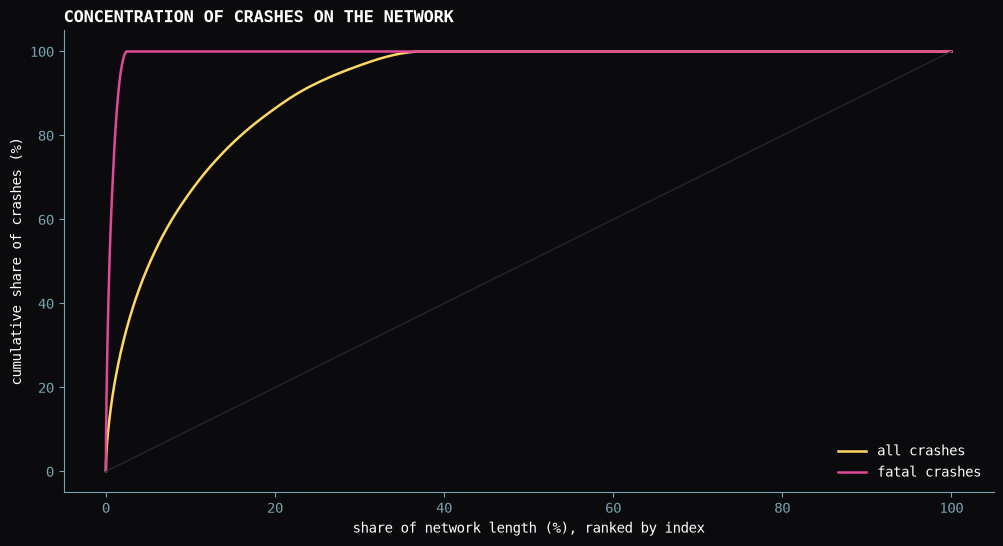

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
for cnt, idx, color, label in [
    ("crash_count", "crash_index", GOLD, "all crashes"),
    ("fatal_cnt", "fatal_index", PULSE, "fatal crashes"),
]:
    d = edges.sort_values(idx, ascending=False)
    cum_len = d["length"].cumsum() / d["length"].sum() * 100
    cum_cnt = d[cnt].cumsum() / d[cnt].sum() * 100
    ax.plot(cum_len, cum_cnt, color=color, label=label, lw=1.8)
    k = np.searchsorted(cum_len.values, 12)
    print(f"{label}: top 12% of network length carries {cum_cnt.iloc[k]:.1f}%")
ax.plot([0, 100], [0, 100], color=FAINT, lw=1)
ax.set_xlabel("share of network length (%), ranked by index")
ax.set_ylabel("cumulative share of crashes (%)")
ax.set_title("CONCENTRATION OF CRASHES ON THE NETWORK", loc="left")
ax.legend(frameon=False)
fig.savefig(OUT / "concentration_curves.png", dpi=400, bbox_inches="tight")
 

In [15]:
node_edges = defaultdict(list)
for i, (u, v) in enumerate(zip(edges["u"], edges["v"])):
    node_edges[u].append(i)
    node_edges[v].append(i)
nbrs = {i: set() for i in range(len(edges))}
for ids in node_edges.values():
    for a in ids:
        nbrs[a].update(ids)
w = libpysal.weights.W({i: [j for j in n if j != i] for i, n in nbrs.items()},
                       silence_warnings=True)
w.transform = "r"
 
edges["crash_dens"] = edges["crash_count"] / edges["length"]
edges["fatal_dens"] = edges["fatal_cnt"] / edges["length"]
 
for col, label in [("crash_dens", "crash density"), ("fatal_dens", "fatal density")]:
    mi = Moran(edges[col].values, w, permutations=999)
    print(f"Global Moran's I, {label}: I={mi.I:.3f}, p={mi.p_sim:.4f}")
 
# Gi* hotspots for both densities (99 permutations for runtime; bump to 999 final)
for col, flag in [("crash_dens", "hot_crash"), ("fatal_dens", "hot_fatal")]:
    gi = G_Local(edges[col].values, w, star=True, permutations=99)
    edges[flag] = (gi.Zs > 1.96) & (gi.p_sim < 0.05)
 
both = (edges["hot_crash"] & edges["hot_fatal"]).sum()
either = (edges["hot_crash"] | edges["hot_fatal"]).sum()
print(f"Hotspot overlap (Jaccard): {both / either:.2f}  "
      f"[crash hotspots {int(edges['hot_crash'].sum())}, "
      f"fatal hotspots {int(edges['hot_fatal'].sum())}, both {int(both)}]")

Global Moran's I, crash density: I=0.051, p=0.0010
Global Moran's I, fatal density: I=0.013, p=0.0050


/Users/cyberhbliu/anaconda3/envs/3.8.0/lib/python3.12/site-packages/esda/getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
/Users/cyberhbliu/anaconda3/envs/3.8.0/lib/python3.12/site-packages/esda/getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values 

Hotspot overlap (Jaccard): 0.08  [crash hotspots 314, fatal hotspots 291, both 46]


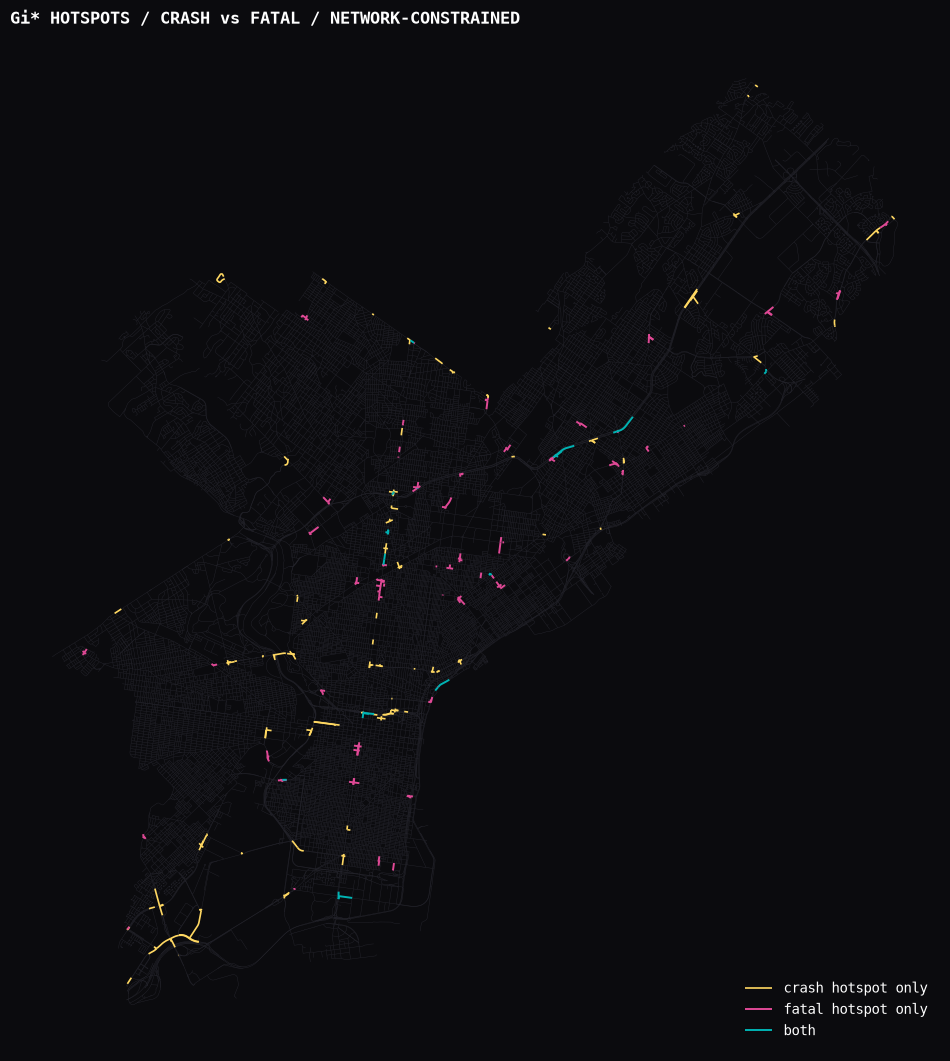

In [22]:
fig, ax = plt.subplots(figsize=(12, 16))
edges.plot(ax=ax, color=FAINT, linewidth=0.3)
edges.loc[edges["hot_crash"] & ~edges["hot_fatal"]].plot(
    ax=ax, color=GOLD, linewidth=1.2, label="crash hotspot only")
edges.loc[edges["hot_fatal"] & ~edges["hot_crash"]].plot(
    ax=ax, color=PULSE, linewidth=1.4, label="fatal hotspot only")
edges.loc[edges["hot_crash"] & edges["hot_fatal"]].plot(
    ax=ax, color=TEAL, linewidth=1.4, label="both")
ax.legend(loc="lower right", frameon=False, labelcolor=BONE)
ax.set_title("Gi* HOTSPOTS / CRASH vs FATAL / NETWORK-CONSTRAINED", loc="left")
ax.set_axis_off()
fig.savefig(OUT / "gi_hotspots_map.png", dpi=400, bbox_inches="tight")
 

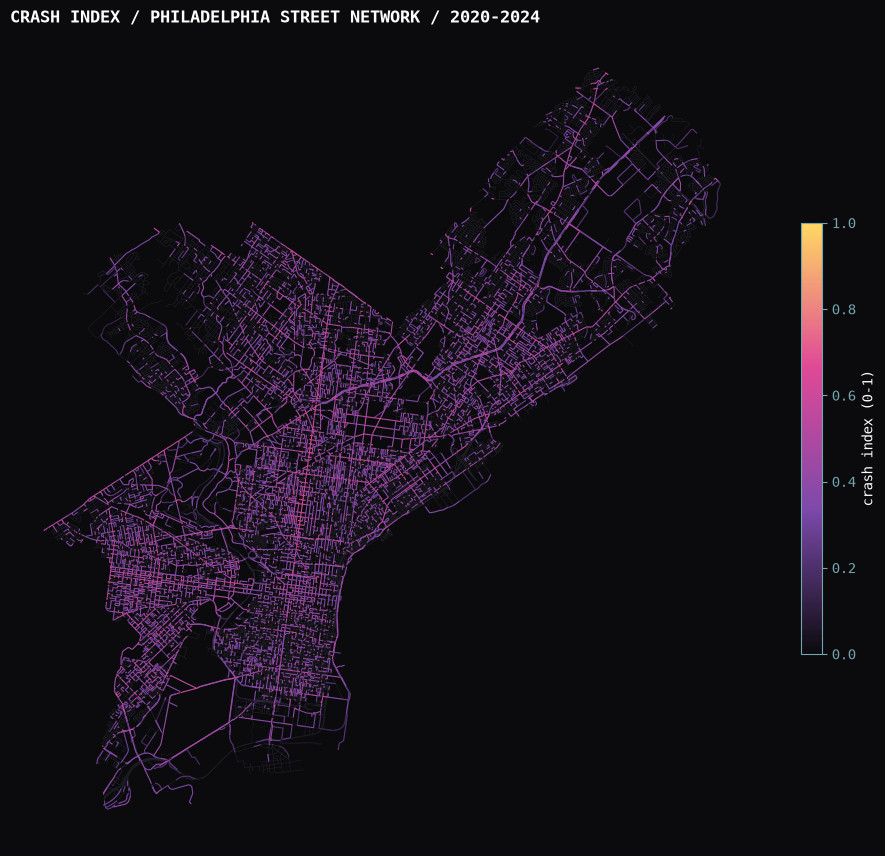

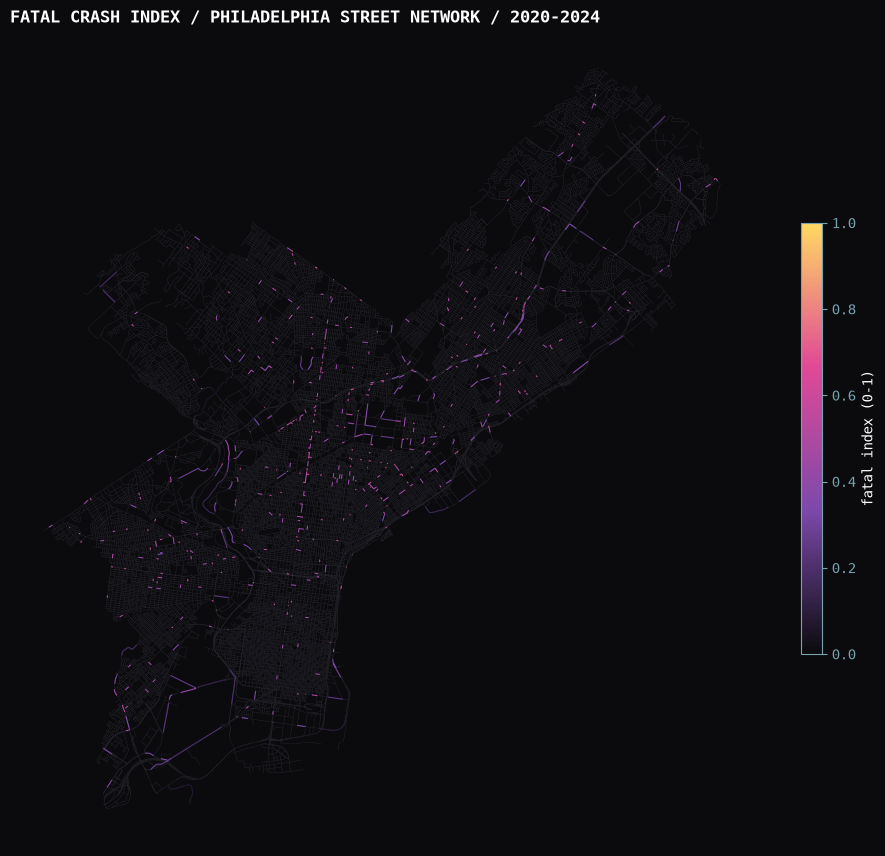

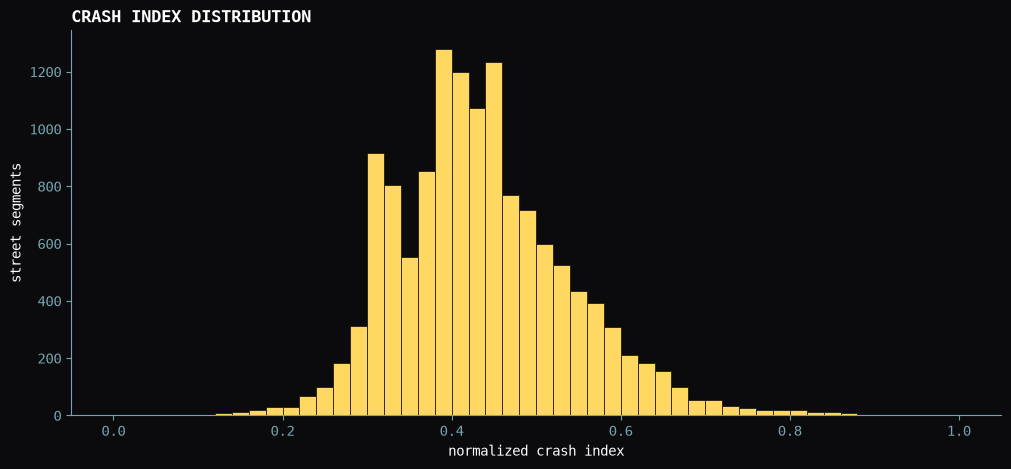

In [34]:
# ---------------------------------------------------------------
# 6. Maps: crash index and fatal index
# ---------------------------------------------------------------
for idx, fname, title in [
    ("crash_index", "crash_index_map.png",
     "CRASH INDEX / PHILADELPHIA STREET NETWORK / 2020-2024"),
    ("fatal_index", "fatal_index_map.png",
     "FATAL CRASH INDEX / PHILADELPHIA STREET NETWORK / 2020-2024"),
]:
    fig, ax = plt.subplots(figsize=(12, 16))
    edges.plot(ax=ax, color=FAINT, linewidth=0.3)
    edges.dropna(subset=[idx]).plot(
        ax=ax, column=idx, cmap=CMAP, linewidth=0.8, legend=True,
        legend_kwds={"label": f"{idx.replace('_', ' ')} (0-1)", "shrink": 0.35},
    )
    ax.set_title(title, loc="left")
    ax.set_axis_off()
    fig.savefig(OUT / fname, dpi=400, bbox_inches="tight")
 
# histogram (log-transform justification)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(edges["crash_index"].dropna(), bins=50, color=GOLD, ec=INK, lw=0.5)
ax.set_xlabel("normalized crash index")
ax.set_ylabel("street segments")
ax.set_title("CRASH INDEX DISTRIBUTION", loc="left")
fig.savefig(OUT / "crash_index_hist.png", dpi=400, bbox_inches="tight")

Segments with a fatal crash: 552; on below-median-crash streets: 138 (25%)


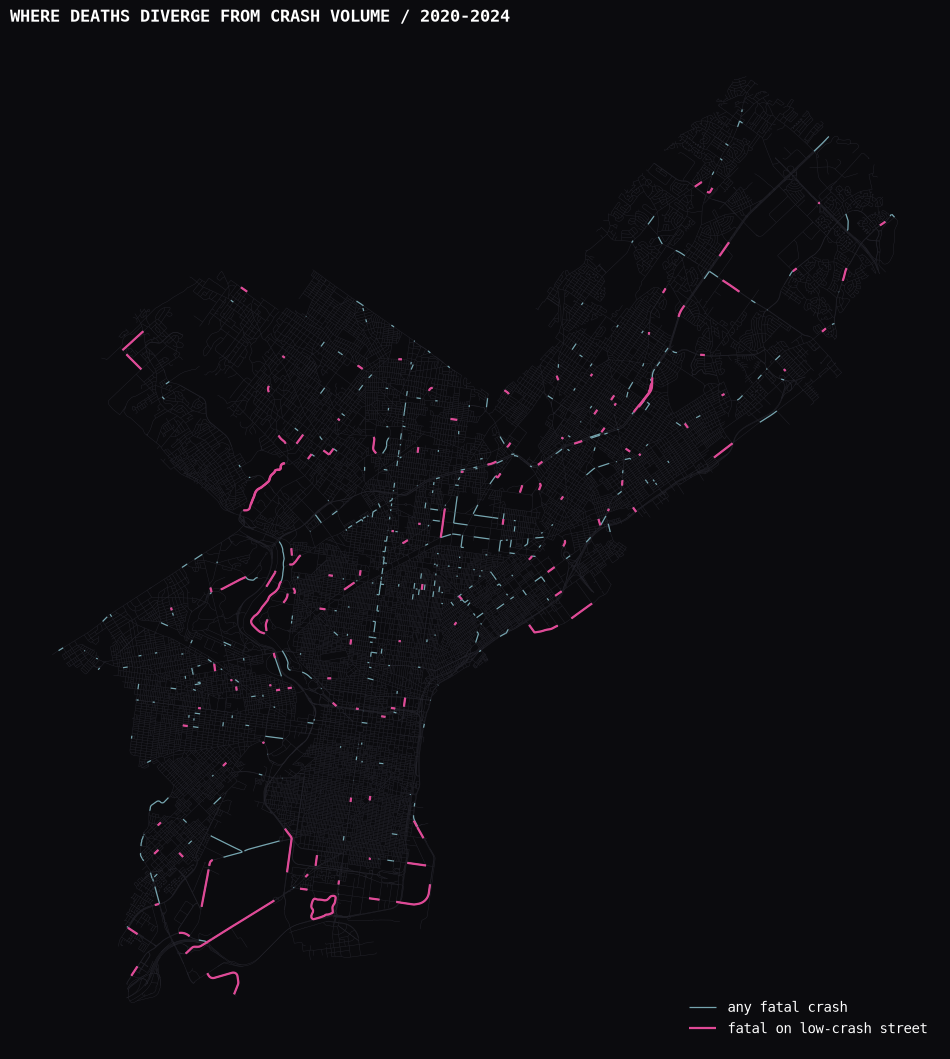

In [28]:
# ---------------------------------------------------------------
# 7. Divergence: fatal crashes on streets with below-median crash index
# ---------------------------------------------------------------
med = edges["crash_index"].median()
edges["quiet_fatal"] = (edges["fatal_cnt"] > 0) & (edges["crash_index"] < med)
 
fig, ax = plt.subplots(figsize=(12, 16))
edges.plot(ax=ax, color=FAINT, linewidth=0.3)
edges.loc[edges["fatal_cnt"] > 0].plot(ax=ax, color=DIM, linewidth=0.9,
                                       label="any fatal crash")
edges.loc[edges["quiet_fatal"]].plot(ax=ax, color=PULSE, linewidth=1.6,
                                     label="fatal on low-crash street")
ax.legend(loc="lower right", frameon=False, labelcolor=BONE)
ax.set_title("WHERE DEATHS DIVERGE FROM CRASH VOLUME / 2020-2024", loc="left")
ax.set_axis_off()
fig.savefig(OUT / "divergence_map.png", dpi=400, bbox_inches="tight")
 
n_qf = int(edges["quiet_fatal"].sum())
n_f = int((edges["fatal_cnt"] > 0).sum())
print(f"Segments with a fatal crash: {n_f}; on below-median-crash streets: "
      f"{n_qf} ({n_qf / n_f * 100:.0f}%)")

In [29]:
# top-15 tables for both indexes
for idx in ["crash_index", "fatal_index"]:
    top = (
        edges.loc[~edges["limited_access"]]
        .dropna(subset=[idx])
        .sort_values(idx, ascending=False)
        .drop_duplicates(subset="name")
        .head(15)[["name", "highway", "crash_count", "fatal_cnt", idx]]
    )
    print(f"\nTop 15 by {idx}:")
    print(top.to_string(index=False))
 


Top 15 by crash_index:
                 name     highway  crash_count  fatal_cnt  crash_index
          City Avenue       trunk         41.0        0.0     1.000000
       Belmont Avenue     primary         20.0        0.0     0.988962
   North Broad Street     primary         28.0        1.0     0.971087
 West Glenwood Avenue   secondary         16.0        0.0     0.948424
    Cheltenham Avenue   secondary         27.0        0.0     0.934665
    East Berks Street residential         16.0        0.0     0.922678
    Kensington Avenue    tertiary         19.0        1.0     0.908502
          Erie Avenue     primary         21.0        3.0     0.907822
   West Girard Avenue     primary         20.0        0.0     0.900913
Tookany Creek Parkway   secondary         10.0        0.0     0.883019
      Haldeman Avenue   secondary         17.0        0.0     0.877919
    South 84th Street     primary         20.0        0.0     0.877047
    South 63rd Street    tertiary         12.0       

In [30]:
# ---------------------------------------------------------------
# 8. Export for the D3 stage
# ---------------------------------------------------------------
keep = edges["crash_count"] > 0
edges.loc[keep].to_crs(epsg=4326)[
    ["name", "highway", "crash_count", "fatal_cnt", "crash_index",
     "fatal_index", "quiet_fatal", "hot_crash", "hot_fatal", "geometry"]
].to_file(OUT / "crash_index_edges.geojson", driver="GeoJSON")
print("\nDone. Outputs in", OUT)


Done. Outputs in /Users/cyberhbliu/Desktop/PERSONAL/2026portfolio/crash/crash_outputs


In [35]:

# corrected concentration statistic for fatal crashes
fatal_len_pct = (
    edges.loc[edges["fatal_cnt"] > 0, "length"].sum() / edges["length"].sum() * 100
)
print(f"All fatal crashes occur on {fatal_len_pct:.1f}% of network length")
 
years = [2020, 2021, 2022, 2023, 2024]
base = edges[["u", "v", "key", "name", "length", "geometry"]].copy()
 

All fatal crashes occur on 2.4% of network length


In [36]:
yr = {}
glo = {"cc": [np.inf, -np.inf], "fc": [np.inf, -np.inf]}
for y in years:
    sub = (
        crash_geo.loc[crash_geo["crash_year"] == y]
        .groupby(["u", "v", "key"])
        .agg(cc=("fatal", "size"), fc=("fatal", "sum"))
        .reset_index()
    )
    ed = base.merge(sub, on=["u", "v", "key"], how="left")
    ed[["cc", "fc"]] = ed[["cc", "fc"]].fillna(0)
    for c in ["cc", "fc"]:
        m = ed[c] > 0
        ed.loc[m, f"log_{c}"] = np.log10(ed.loc[m, c] / ed.loc[m, "length"])
        glo[c][0] = min(glo[c][0], ed[f"log_{c}"].min())
        glo[c][1] = max(glo[c][1], ed[f"log_{c}"].max())
    yr[y] = ed

In [37]:
for y in years:
    ed = yr[y]
    for c, idx in [("cc", "crash_index"), ("fc", "fatal_index")]:
        lo, hi = glo[c]
        ed[idx] = (ed[f"log_{c}"] - lo) / (hi - lo)
 
    for idx, cnt, fname, title in [
        ("crash_index", "cc", f"crash_index_map_{y}.png",
         f"CRASH INDEX / PHILADELPHIA / {y}"),
        ("fatal_index", "fc", f"fatal_index_map_{y}.png",
         f"FATAL CRASH INDEX / PHILADELPHIA / {y}"),
    ]:
        fig, ax = plt.subplots(figsize=(12, 16))
        ed.plot(ax=ax, color=FAINT, linewidth=0.3)
        ed.dropna(subset=[idx]).plot(
            ax=ax, column=idx, cmap=CMAP, linewidth=0.9, legend=True,
            vmin=0, vmax=1,
            legend_kwds={"label": f"{idx.replace('_', ' ')} (0-1, common scale)",
                         "shrink": 0.35},
        )
        ax.set_title(title, loc="left")
        ax.set_axis_off()
        fig.savefig(OUT / fname, dpi=400, bbox_inches="tight")
        plt.close(fig)
 
    med_y = ed["crash_index"].median()
    ed["quiet_fatal"] = (ed["fc"] > 0) & (ed["crash_index"] < med_y)
 
    fig, ax = plt.subplots(figsize=(12, 16))
    ed.plot(ax=ax, color=FAINT, linewidth=0.3)
    ed.loc[ed["fc"] > 0].plot(ax=ax, color=DIM, linewidth=1.0,
                              label="any fatal crash")
    ed.loc[ed["quiet_fatal"]].plot(ax=ax, color=PULSE, linewidth=1.8,
                                   label="fatal on low-crash street")
    ax.legend(loc="lower right", frameon=False, labelcolor=BONE)
    ax.set_title(f"WHERE DEATHS DIVERGE FROM CRASH VOLUME / {y}", loc="left")
    ax.set_axis_off()
    fig.savefig(OUT / f"divergence_map_{y}.png", dpi=400, bbox_inches="tight")
    plt.close(fig)
 
    n_f = int((ed["fc"] > 0).sum())
    n_qf = int(ed["quiet_fatal"].sum())
    print(f"{y}: crashes {int(ed['cc'].sum())}, fatal crashes {int(ed['fc'].sum())}, "
          f"fatal segments {n_f}, quiet-fatal {n_qf} "
          f"({(n_qf / n_f * 100) if n_f else 0:.0f}%)")

2020: crashes 8110, fatal crashes 143, fatal segments 139, quiet-fatal 61 (44%)
2021: crashes 8458, fatal crashes 118, fatal segments 113, quiet-fatal 52 (46%)
2022: crashes 6911, fatal crashes 120, fatal segments 118, quiet-fatal 50 (42%)
2023: crashes 6904, fatal crashes 120, fatal segments 118, quiet-fatal 50 (42%)
2024: crashes 5920, fatal crashes 119, fatal segments 116, quiet-fatal 49 (42%)


In [38]:
for y in years:
    yr[y].loc[yr[y]["cc"] > 0].to_crs(epsg=4326)[
        ["name", "cc", "fc", "crash_index", "fatal_index", "quiet_fatal", "geometry"]
    ].to_file(OUT / f"crash_edges_{y}.geojson", driver="GeoJSON")
print("Yearly outputs done.")

Yearly outputs done.


In [42]:
# ---------------------------------------------------------------
# 10. Randomization test: H0 = fatal crashes are a random sample of crashes
#     Draw 620 of the 36,303 crashes as "fatal", 999 times; compare
#     observed fatal-length share and quiet-fatal share to the null
# ---------------------------------------------------------------
rng = np.random.default_rng(2272)
n_sims = 999
n_fatal = int(crash_geo["fatal"].sum())
 
# crash -> edge row position (edges is reset_index, align via merge once)
edge_pos = edges.reset_index().set_index(["u", "v", "key"])["index"]
crash_edge = crash_geo.set_index(["u", "v", "key"]).index.map(edge_pos).values
 
lengths = edges["length"].values
total_len = lengths.sum()
med = edges["crash_index"].median()
below_med = (edges["crash_index"] < med).fillna(False).values
 
obs_len_share = lengths[edges["fatal_cnt"].values > 0].sum() / total_len * 100
obs_quiet = (
    ((edges["fatal_cnt"].values > 0) & below_med).sum()
    / (edges["fatal_cnt"].values > 0).sum() * 100
)
 
null_len, null_quiet = [], []
for _ in range(n_sims):
    pick = rng.choice(crash_edge, size=n_fatal, replace=False)
    hit = np.zeros(len(edges), dtype=bool)
    hit[np.unique(pick)] = True
    null_len.append(lengths[hit].sum() / total_len * 100)
    null_quiet.append((hit & below_med).sum() / hit.sum() * 100)
 
null_len = np.array(null_len)
null_quiet = np.array(null_quiet)
 
for obs, null, label in [
    (obs_len_share, null_len, "fatal-bearing length share (%)"),
    (obs_quiet, null_quiet, "quiet-fatal share (%)"),
]:
    p = (np.sum(np.abs(null - null.mean()) >= np.abs(obs - null.mean())) + 1) / (n_sims + 1)
    print(f"{label}: observed {obs:.1f} | null {null.mean():.1f} "
          f"[{np.percentile(null, 2.5):.1f}, {np.percentile(null, 97.5):.1f}] | p={p:.3f}")

fatal-bearing length share (%): observed 2.4 | null 2.0 [1.9, 2.2] | p=0.001
quiet-fatal share (%): observed 25.0 | null 26.9 [23.5, 30.5] | p=0.293


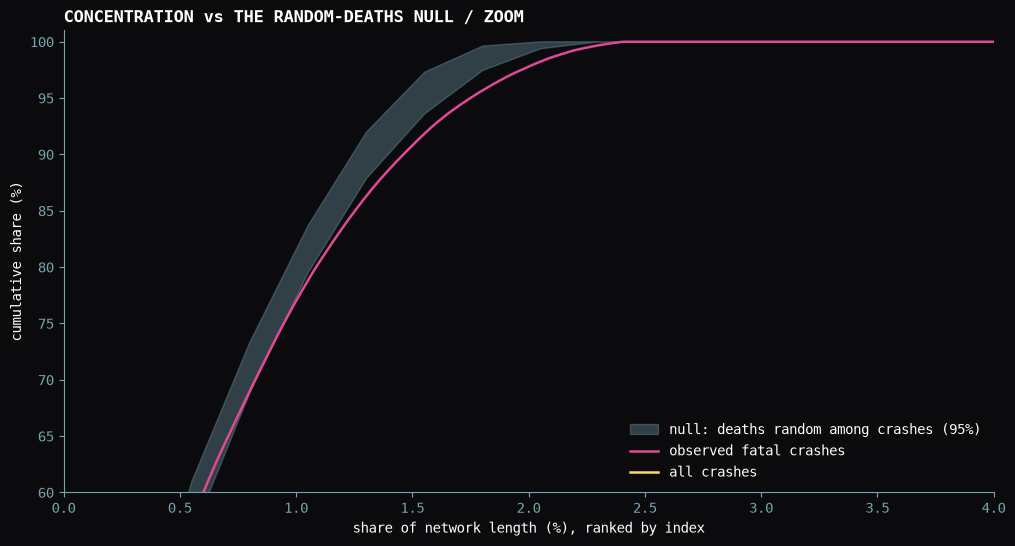

In [45]:
# concentration curve with null envelope
d = edges.sort_values("fatal_index", ascending=False)
cum_len_obs = d["length"].cumsum() / total_len * 100
cum_fat_obs = d["fatal_cnt"].cumsum() / d["fatal_cnt"].sum() * 100
 
grid = np.linspace(0.05, 100, 400)
null_curves = np.empty((200, len(grid)))
for s in range(200):
    pick = rng.choice(crash_edge, size=n_fatal, replace=False)
    fc = np.bincount(pick, minlength=len(edges)).astype(float)
    m = fc > 0
    logd = np.full(len(edges), -np.inf)
    logd[m] = np.log10(fc[m] / lengths[m])
    order = np.argsort(-logd)
    cl = lengths[order].cumsum() / total_len * 100
    cf = fc[order].cumsum() / n_fatal * 100
    null_curves[s] = np.interp(grid, cl, cf)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(grid, np.percentile(null_curves, 2.5, axis=0),
                np.percentile(null_curves, 97.5, axis=0),
                color=DIM, alpha=0.35,
                label="null: deaths random among crashes (95%)")
ax.plot(cum_len_obs, cum_fat_obs, color=PULSE, lw=1.8, label="observed fatal crashes")
d2 = edges.sort_values("crash_index", ascending=False)
ax.plot(d2["length"].cumsum() / total_len * 100,
        d2["crash_count"].cumsum() / d2["crash_count"].sum() * 100,
        color=GOLD, lw=1.8, label="all crashes")
ax.plot([0, 100], [0, 100], color=FAINT, lw=1)
ax.set_xlim(0, 30)
ax.set_xlabel("share of network length (%), ranked by index")
ax.set_ylabel("cumulative share (%)")
ax.set_title("CONCENTRATION vs THE RANDOM-DEATHS NULL", loc="left")
ax.legend(frameon=False, loc="lower right")
fig.savefig(OUT / "concentration_null_envelope.png", dpi=400, bbox_inches="tight")

# zoomed panel: the observed-vs-null separation lives below 4%
ax.set_xlim(0, 4)
ax.set_ylim(60, 101)
ax.set_title("CONCENTRATION vs THE RANDOM-DEATHS NULL / ZOOM", loc="left")
fig.savefig(OUT / "concentration_null_zoom.png", dpi=400, bbox_inches="tight")
 

In [47]:
crash.loc[crash["fatal"], "fatal_count"].sum()

np.int64(647)